<a href="https://colab.research.google.com/github/Arczisork/Sztuczna-inteligencja/blob/main/sztuczna_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)



2.19.0


In [34]:
observations = 1000
xs = np.random.uniform(low=-10,high=10,size=(observations,1))
zs = np.random.uniform(low=-10,high=10,size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)


(1000, 2)


In [35]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset',inputs=inputs,targets=targets)
print(targets.shape)


(1000, 1)


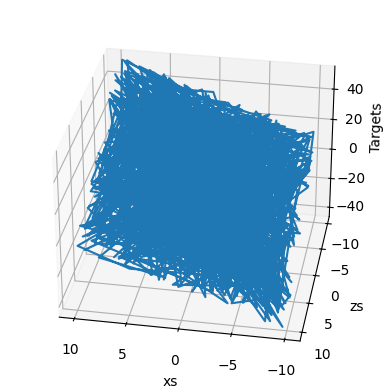

In [36]:

targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [37]:
init_range= 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)


[[0.08744014]
 [0.05218265]] [0.06176822]


In [38]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas **2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)


228.7607259921431
36.48295093621098
14.111218397546377
11.165986445470498
10.45697630496292
10.018517558774317
9.6251711888426
9.250571633400945
8.891161405197993
8.54601665721484
8.214535816711658
7.896173885998037
7.590411196154086
7.296749075993909
7.014708638869414
6.743829955782719
6.483671300088254
6.233808426553707
5.993833879466012
5.763356328178218
5.541999928958881
5.329403712097113
5.125220993262984
4.92911880816341
4.740777369571491
4.559889545843975
4.38616036007635
4.21930650907891
4.0590559013893435
3.90514721356847
3.757329464055589
3.6153616038885077
3.479012123620823
3.3480586757954662
3.2222877123588516
3.1014941364243684
2.985480967817346
2.87405902185607
2.7670466008450467
2.6642691977774273
2.565559211763413
2.4707556747205834
2.3797039888804585
2.2922556746832425
2.2082681286496344
2.12760439083487
2.0501329214857678
1.9757273865365745
1.9042664515938237
1.8356335840742344
1.7697168631730162
1.7064087973526698
1.6456061490546878
1.5872097663482645
1.5311244212415

In [39]:
print(weights, biases)

[[ 1.99800282]
 [-2.99728004]] [4.33566717]


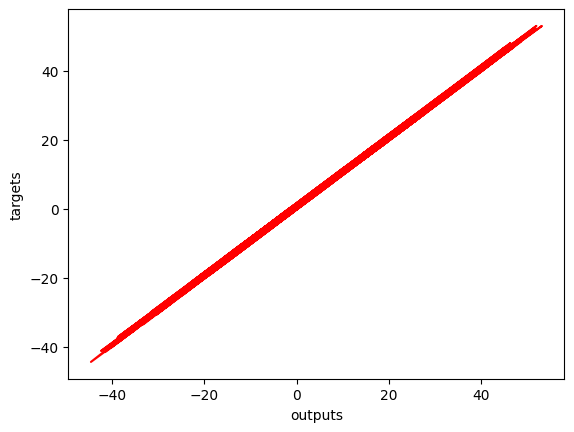

In [40]:
plt.plot(outputs, targets, color='red')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()